In [135]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import MinMaxScaler
import joblib

In [136]:
print("Generating environmental dataset")
np.random.seed(42)
timesteps = 4000

Generating environmental dataset


In [137]:
time_axis = np.linspace(0, 150, timesteps)
traffic_seq = 50 + 35 * np.sin(time_axis) + np.random.uniform(-7, 7, timesteps)
wind_seq = 15 + 10 * np.cos(time_axis * 0.5) + np.random.uniform(-3, 3, timesteps)
factory_seq = 60 + 20 * np.sin(time_axis * 1.2) + np.random.uniform(-12, 12, timesteps)
temp_seq = 28 + 8 * np.sin(time_axis - 1.5) + np.random.uniform(-2, 2, timesteps)

In [138]:
num_events = 20
event_starts = np.random.choice(timesteps - 30, num_events, replace=False)

In [139]:
for start_idx in event_starts:
    duration = np.random.randint(6, 18)

    if np.random.rand() > 0.5:
        traffic_seq[start_idx:start_idx+duration] = np.linspace(traffic_seq[start_idx], 100, duration)
        factory_seq[start_idx:start_idx+duration] = np.linspace(factory_seq[start_idx], 150, duration)
        wind_seq[start_idx:start_idx+duration] = np.linspace(wind_seq[start_idx], 2, duration)
    else:
        wind_seq[start_idx:start_idx+duration] = np.linspace(wind_seq[start_idx], 35, duration)
        factory_seq[start_idx:start_idx+duration] = np.linspace(factory_seq[start_idx], 20, duration)
        traffic_seq[start_idx:start_idx+duration] = np.linspace(traffic_seq[start_idx], 10, duration)
traffic_seq = np.clip(traffic_seq, 10, 100)
wind_seq = np.clip(wind_seq, 2, 35)
factory_seq = np.clip(factory_seq, 20, 150)
temp_seq = np.clip(temp_seq, 15, 45)

In [140]:
base_aqi = (traffic_seq * 1.4) + (factory_seq * 1.1) - (wind_seq * 1.6) + (temp_seq * 0.3) + 30
target_aqi = np.clip(base_aqi + np.random.normal(0, 5, timesteps), 15, 500)

In [141]:
df = pd.DataFrame({
    'traffic_density': traffic_seq,
    'wind_speed': wind_seq,
    'factory_emissions': factory_seq,
    'temperature': temp_seq,
    'aqi': target_aqi
})

In [142]:
df.to_csv('smart_city_aqi_data.csv', index=False)

DATA PREPROCESSING

In [143]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

In [144]:
def create_sequences(data, window_size=24):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), :])
        y.append(data[i + window_size, 4])
    return np.array(X), np.array(y)

WINDOW_SIZE = 24
X, y = create_sequences(scaled_data, WINDOW_SIZE)

split_idx = int(len(X) * 0.8)
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

BIDIRECTIONAL LSTM RNN MODEL TRAINING

In [145]:
model = Sequential([
    # THE FIX: input_shape is now 5 features instead of 4
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(WINDOW_SIZE, 5)),
    Dropout(0.1),

    Bidirectional(LSTM(32, return_sequences=False)),
    Dropout(0.1),

    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [146]:
##usign adam optimizer -loss function ke liye
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=opt, loss='mean_squared_error', metrics=['mae'])

In [147]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=26,
    restore_best_weights=True,
    verbose=1
)

In [148]:
##main training
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0174 - mae: 0.0897 - val_loss: 0.0062 - val_mae: 0.0499
Epoch 2/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0060 - mae: 0.0531 - val_loss: 0.0053 - val_mae: 0.0463
Epoch 3/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0050 - mae: 0.0486 - val_loss: 0.0047 - val_mae: 0.0432
Epoch 4/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0046 - mae: 0.0463 - val_loss: 0.0043 - val_mae: 0.0418
Epoch 5/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0043 - mae: 0.0451 - val_loss: 0.0040 - val_mae: 0.0408
Epoch 6/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0042 - mae: 0.0442 - val_loss: 0.0036 - val_mae: 0.0400
Epoch 7/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0040 - mae: 0.0435 - val_loss: 0.0037 - val_mae: 0.0415
Epoch 8/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0040 - mae: 0.0435 - val_loss: 0.0037 - val_mae: 0.0426
Epoch 9/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.003

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
 Validation R² Score: 87.25%


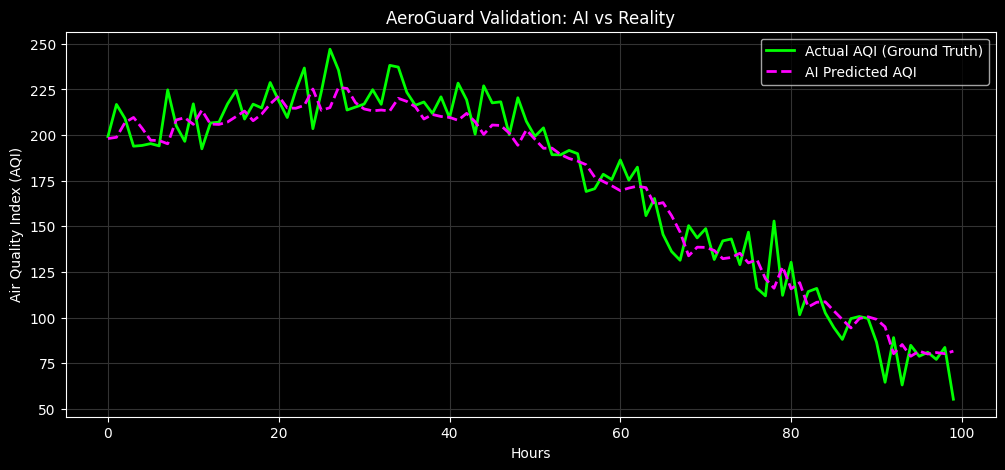

In [149]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
##getting the predcition of model
raw_predictions = model.predict(X_val)

pred_1d = raw_predictions.flatten()
if len(y_val.shape) > 1 and y_val.shape[1] > 1:
    actual_1d = y_val[:, -1]
else:
    actual_1d = y_val.flatten()
dummy_pred = np.zeros((len(pred_1d), 5))
dummy_pred[:, 4] = pred_1d
unscaled_predictions = scaler.inverse_transform(dummy_pred)[:, 4]

dummy_actual = np.zeros((len(actual_1d), 5))
dummy_actual[:, 4] = actual_1d
unscaled_actual = scaler.inverse_transform(dummy_actual)[:, 4]

mae = mean_absolute_error(unscaled_actual, unscaled_predictions)
r2 = r2_score(unscaled_actual, unscaled_predictions)
print(f" Validation R² Score: {r2 * 100:.2f}%")

plt.style.use('dark_background')
plt.figure(figsize=(12,5))
plt.plot(unscaled_actual[:100], label="Actual AQI (Ground Truth)", color="#00FF00", linewidth=2)
plt.plot(unscaled_predictions[:100], label="AI Predicted AQI",color="#FF00FF",linestyle="dashed",linewidth=2)
plt.title("AeroGuard Validation: AI vs Reality")
plt.xlabel("Hours")
plt.ylabel("Air Quality Index (AQI)")
plt.legend()
plt.grid(color='#333333')
plt.show()

In [150]:
joblib.dump(scaler, 'aqi_pipeline_scaler.pkl')

['aqi_pipeline_scaler.pkl']